In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df=pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\IntelliPaat\EDA CSV files\OnlineRetail(Capstone4).csv",encoding='ISO-8859-1')

In [67]:
df.shape

(541909, 8)

In [68]:
df.info()

# Attribute Information:
# InvoiceNo: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.
# StockCode: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.
# Description: Product (item) name. Nominal.
# Quantity: The quantities of each product (item) per transaction. Numeric.
# InvoiceDate: Invice Date and time. Numeric, the day and time when each transaction was generated.
# UnitPrice: Unit price. Numeric, Product price per unit in sterling.
# CustomerID: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.
# Country: Country name. Nominal, the name of the country where each customer resides.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [70]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
print("Percentage of customers missing: ", round(df['CustomerID'].isnull().sum() * 100 / len(df),2),"%" )
print("Percentage of Product Descriptions missing: ", round(df['Description'].isnull().sum() * 100 / len(df),2),"%" )
print("Avg. number of products per order : ",  round(df['StockCode'].count() / df['InvoiceNo'].nunique(),2) )

Percentage of customers missing:  24.93 %
Percentage of Product Descriptions missing:  0.27 %
Avg. number of products per order :  20.92


In [7]:
# Having large number of null in Customer ID may create problem- 
# Instead of deleting such a large group- we will assign InvoiceNo as the CustomerID for this group

df1=df[df.CustomerID.isnull()]
df1['CustomerID']=df1['InvoiceNo']
df1.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_868\1796878095.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['CustomerID']=df1['InvoiceNo']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,536414,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,536544,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,536544,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,536544,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,536544,United Kingdom


In [8]:
df=df.dropna(subset=['CustomerID'])
df=pd.concat([df, df1], axis=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 541909 entries, 0 to 541540
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   541909 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 37.2+ MB


In [9]:
print("Number of transactions in the dataset : ", df['InvoiceNo'].nunique())
print("Number of different products bought in the dataset : ", df['StockCode'].nunique())
print("Number of unique customers in the dataset :", df['CustomerID'].nunique())
print('Number of countries in the dataset: ', df['Country'].nunique())

Number of transactions in the dataset :  25900
Number of different products bought in the dataset :  4070
Number of unique customers in the dataset : 8082
Number of countries in the dataset:  38


In [10]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [11]:
# Find the top 5 customers by total spending amount.

df.groupby('CustomerID') ['UnitPrice'].sum().sort_values(ascending=False).reset_index()[:5]

,CustomerID,UnitPrice
0,14096.0,41376.33
1,15098.0,40278.90
2,14911.0,31060.66
3,12744.0,25108.89
4,16029.0,24111.14


In [12]:
# Find the bottom 5 customers by total spending amount.
df.groupby('CustomerID') ['UnitPrice'].sum().sort_values(ascending=True).reset_index()[:5]

,CustomerID,UnitPrice
0,A563186,-11062.06
1,A563187,-11062.06
2,564927,0.00
3,543258,0.00
4,543259,0.00


In [13]:
# Covert Date to Date time and drop time potion

df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate']=df['InvoiceDate'].dt.normalize()
df.sample(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
281952,561614,20725,LUNCH BAG RED RETROSPOT,10,2011-07-28,1.65,13871.0,United Kingdom
185365,552811,15056N,EDWARDIAN PARASOL NATURAL,3,2011-05-11,5.95,17677.0,United Kingdom
448029,575007,22483,RED GINGHAM TEDDY BEAR,6,2011-11-08,2.95,14140.0,United Kingdom


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 541909 entries, 0 to 541540
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   541909 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 37.2+ MB


In [15]:
df['Invoice_Value']=df['Quantity'] *df['UnitPrice']

In [16]:
df.sample()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Value
69566,541972,22558,CLOTHES PEGS RETROSPOT PACK 24,12,2011-01-24,1.49,12935.0,United Kingdom,17.88


In [17]:
# Top 5 customer by number of Invoices
df.groupby('CustomerID') ['InvoiceNo'].nunique().sort_values(ascending=False).reset_index()[:5]


,CustomerID,InvoiceNo
0,14911.0,248
1,12748.0,224
2,17841.0,169
3,14606.0,128
4,15311.0,118


In [18]:
# Bottom 5 customer by number of Invoices
df.groupby('CustomerID') ['InvoiceNo'].nunique().sort_values(ascending=True).reset_index()[:5]


,CustomerID,InvoiceNo
0,C580605,1
1,16881.0,1
2,551326,1
3,551327,1
4,551328,1


In [19]:
# Top 5 dates of maximum sales
df.groupby('InvoiceDate') ['Invoice_Value'].sum().sort_values(ascending=False).reset_index()[:5]

,InvoiceDate,Invoice_Value
0,2011-11-14,112141.11
1,2011-09-20,109286.21
2,2011-12-08,81417.78
3,2011-11-23,78480.70
4,2011-10-05,75244.43


In [20]:
# Top 5 dates of minimum sales
df.groupby('InvoiceDate') ['Invoice_Value'].sum().sort_values(ascending=True).reset_index()[:5]

,InvoiceDate,Invoice_Value
0,2011-01-05,-1566.23
1,2011-02-06,3457.11
2,2011-03-13,4137.62
3,2011-08-14,5150.18
4,2011-02-13,5535.40


In [21]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['StockCode']=le.fit_transform(df['StockCode'])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 541909 entries, 0 to 541540
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   InvoiceNo      541909 non-null  object        
 1   StockCode      541909 non-null  int32         
 2   Description    540455 non-null  object        
 3   Quantity       541909 non-null  int64         
 4   InvoiceDate    541909 non-null  datetime64[ns]
 5   UnitPrice      541909 non-null  float64       
 6   CustomerID     541909 non-null  object        
 7   Country        541909 non-null  object        
 8   Invoice_Value  541909 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 39.3+ MB


In [23]:
# Top 5 items by Sales Quantity

df.groupby(['StockCode','Description']) ['Quantity'].sum().sort_values(ascending=False).reset_index()[:5]

,StockCode,Description,Quantity
0,2997,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
1,3515,JUMBO BAG RED RETROSPOT,47363
2,3305,ASSORTED COLOUR BIRD ORNAMENT,36381
3,1147,POPCORN HOLDER,36334
4,454,PACK OF 72 RETROSPOT CAKE CASES,36039


In [24]:
# Bottom 5 items by Sales Quantity
df.groupby(['StockCode','Description']) ['Quantity'].sum().sort_values(ascending=True).reset_index()[:5]

,StockCode,Description,Quantity
0,1907,printing smudges/thrown away,-19200
1,1905,Printing smudges/thrown away,-9058
2,2821,throw away,-5368
3,2931,"Unsaleable, destroyed.",-4830
4,173,wrongly marked. 23343 in box,-3100


In [25]:
country_counts=pd.DataFrame(df['Country'].value_counts())
country_counts.reset_index(inplace=True)
country_counts.columns=['Country', 'Count']
country_counts.head(3)

,Country,Count
0,United Kingdom,495478
1,Germany,9495
2,France,8557


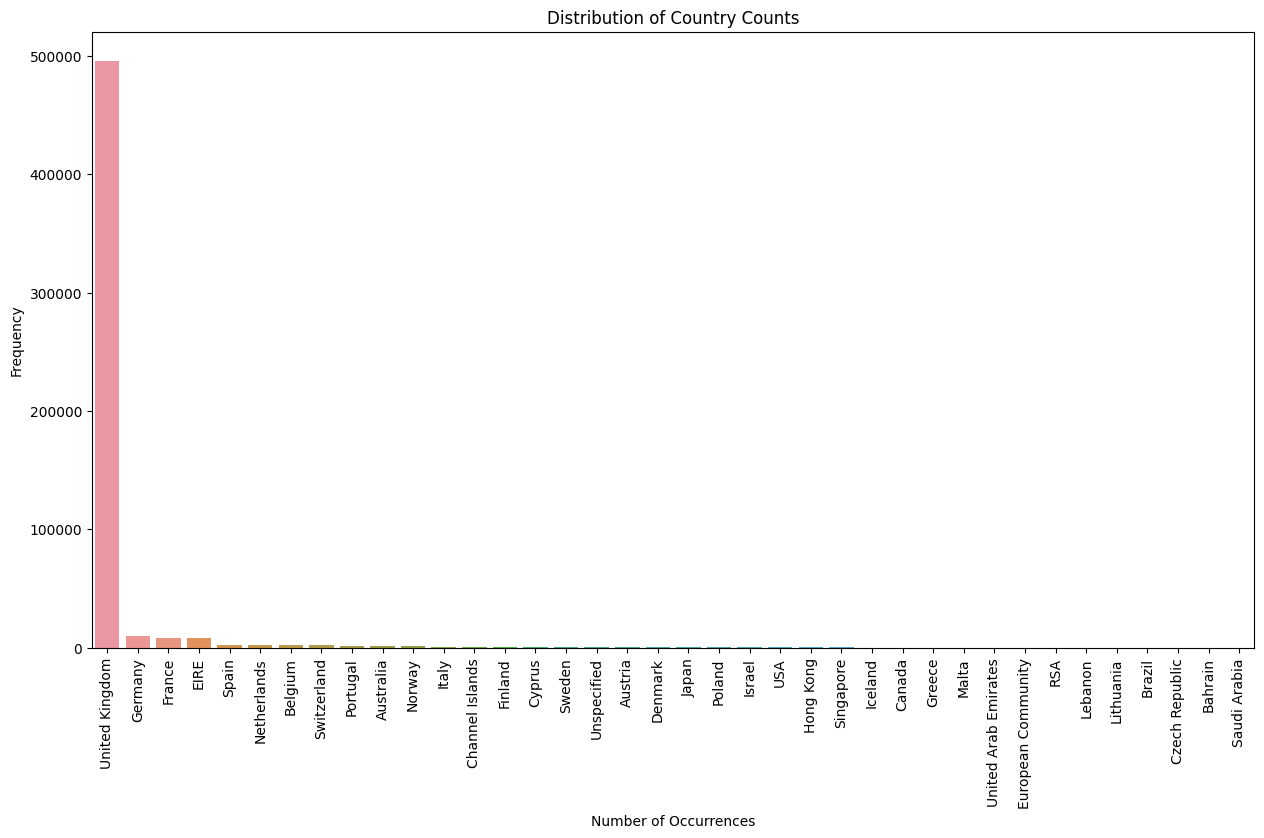

In [26]:
plt.figure(figsize=(15,8))
sns.barplot(data=country_counts, x=country_counts['Country'], y=country_counts['Count'])
plt.title("Distribution of Country Counts")
plt.xlabel("Number of Occurrences")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

In [27]:
# Since UK has significantly higher number of customners, we will focus our analysis on UK only for customer segmentation.
uk=df[df['Country']=='United Kingdom']
uk.sample(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Value
418241,572703,1854,60 CAKE CASES DOLLY GIRL DESIGN,2,2011-10-25,0.55,16110.0,United Kingdom,1.10
351104,567661,2048,SET OF 4 JAM JAR MAGNETS,1,2011-09-21,2.08,13959.0,United Kingdom,2.08
487486,577768,2117,CHERUB HEART DECORATION GOLD,1,2011-11-21,1.63,577768,United Kingdom,1.63


In [28]:
# We will do this analysis basis RFM model for retail customer analysis.
# R- stands for recency
# F- stands for frequency
# M- stands for Monetary Value

# RFM analysis will help us answer the following questions
# Who are our best customers?
# Who has the potential to be converted into more profitable customers?
# Which customers do we need to retain?
# Which group of customers is most likely to respond to our marketing campaign?

# This will help in the following
# 1. Recognize who are our most valuable customers
# 2. Increase revenue
# 3. Increase customer retention
# 4. Learn more about the trends and behaviors of our customers
# 5. Define customers that are at risk

In [29]:
uk.sample(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Invoice_Value
421113,572921,1769,HAND WARMER OWL DESIGN,2,2011-10-26,2.10,15993.0,United Kingdom,4.2
197560,553915,1317,JUMBO BAG PINK POLKADOT,10,2011-05-19,2.08,18225.0,United Kingdom,20.8
426271,573347,425,PARTY METAL SIGN,2,2011-10-30,1.45,13137.0,United Kingdom,2.9


In [30]:
last_purchase_date=pd.DataFrame(uk.groupby('CustomerID')['InvoiceDate'].max().reset_index())
last_purchase_date.rename(columns={'InvoiceDate': 'last_invoice_date'}, inplace=True)
last_purchase_date.head()

,CustomerID,last_invoice_date
0,12346.0,2011-01-18
1,12747.0,2011-12-07
2,12748.0,2011-12-09
3,12749.0,2011-12-06
4,12820.0,2011-12-06


In [31]:
last_purchase_date['last_invoice_date']= pd.to_datetime(last_purchase_date['last_invoice_date']).dt.date

In [32]:
from datetime import date
today=date.today()
today

datetime.date(2024, 10, 24)

In [33]:
last_purchase_date['recency']= last_purchase_date['last_invoice_date'].apply(lambda x: (today-x).days)

In [34]:
last_purchase_date.drop(columns=['last_invoice_date'], inplace=True)
last_purchase_date.head(5)

,CustomerID,recency
0,12346.0,5028
1,12747.0,4705
2,12748.0,4703
3,12749.0,4706
4,12820.0,4706


In [35]:
frequency=pd.DataFrame(uk.groupby('CustomerID')['InvoiceNo'].count().reset_index())
frequency.rename(columns={'InvoiceNo': 'frequency'}, inplace=True)

In [36]:
frequency.head()

,CustomerID,frequency
0,12346.0,2
1,12747.0,103
2,12748.0,4642
3,12749.0,231
4,12820.0,59


In [37]:
value=pd.DataFrame(uk.groupby('CustomerID')['Invoice_Value'].sum().reset_index()).rename(columns={'Invoice_Value':'value'})
value.head()

,CustomerID,value
0,12346.0,0.00
1,12747.0,4196.01
2,12748.0,29072.10
3,12749.0,3868.20
4,12820.0,942.34


In [38]:
rfm=last_purchase_date.merge(frequency, on='CustomerID').merge(value, on='CustomerID')
rfm.set_index('CustomerID', inplace=True)
rfm.head()

,recency,frequency,value
CustomerID,,,
12346.0,5028,2,0.00
12747.0,4705,103,4196.01
12748.0,4703,4642,29072.10
12749.0,4706,231,3868.20
12820.0,4706,59,942.34


In [39]:
rfm.sample(4)

,recency,frequency,value
CustomerID,,,
573274,4745,65,2362.83
16713.0,4721,632,6840.23
15787.0,4729,206,948.05
542880,5014,1,0.00


In [40]:
for i,col in enumerate(rfm.columns):
    cutoff=rfm[col].quantile(0.5)
    rfm[i]=rfm[col].apply(lambda x: 'L' if(x<cutoff) else 'H')

In [41]:
rfm.rename(columns={0:'recency_category', 1: 'frequency_category', 2:'value_category'}, inplace=True)
rfm.sample(3)

,recency,frequency,value,recency_category,frequency_category,value_category
CustomerID,,,,,,
545599,4983,1,0.0,H,L,L
569935,4767,1,0.0,L,L,L
16366.0,4721,18,327.3,L,H,H


In [42]:
rfm['cust_category']=rfm['recency_category']+rfm['frequency_category']+rfm['value_category']

###### 

In [43]:
rfm.sample(5)

,recency,frequency,value,recency_category,frequency_category,value_category,cust_category
CustomerID,,,,,,,
14762.0,4966,21,300.52,H,H,H,HHH
564927,4803,1,0.00,H,L,L,HLL
14754.0,4747,41,638.05,L,H,H,LHH
13941.0,4724,47,4912.41,L,H,H,LHH
14641.0,4724,7,110.46,L,L,L,LLL


In [44]:
rfm['cust_category'].replace(['HHH','HHL', 'HLH', 'HLL', 'LHH','LHL','LLH','LLL'],['Champions','Loyal Customers','At Risk','Recent Customers','Can’t Lose','Promising','Needing Attention','Lost'], inplace=True)


In [45]:
rfm.sample(10)

,recency,frequency,value,recency_category,frequency_category,value_category,cust_category
CustomerID,,,,,,,
545600,4983,1,0.00,H,L,L,Recent Customers
16243.0,4736,51,409.10,L,H,H,Can’t Lose
16185.0,4719,31,529.41,L,H,H,Can’t Lose
548220,4957,1,0.00,H,L,L,Recent Customers
555321,4893,21,223.06,H,H,L,Loyal Customers
16997.0,4991,12,702.00,H,L,H,At Risk
560578,4846,1,0.00,H,L,L,Recent Customers
13558.0,4708,175,605.06,L,H,H,Can’t Lose
14803.0,4865,44,845.55,H,H,H,Champions


In [46]:
category_split= pd.DataFrame(rfm['cust_category'].value_counts().reset_index())
category_split

,index,cust_category
0,Can’t Lose,2322
1,Recent Customers,2282
2,Champions,1158
3,Lost,1137
4,Loyal Customers,216
5,Needing Attention,159
6,Promising,158
7,At Risk,155


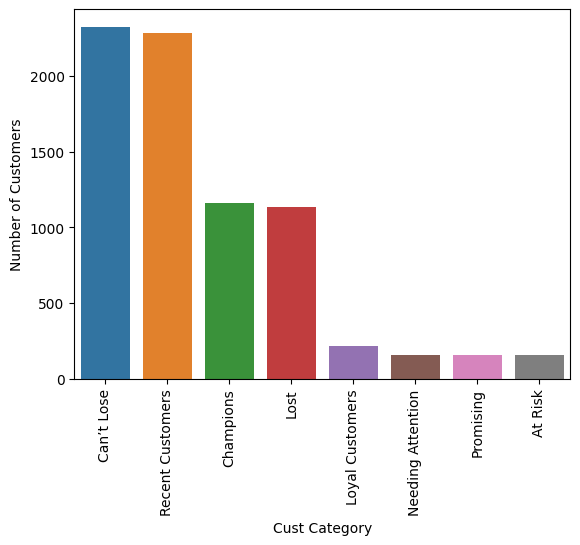

In [47]:
sns.barplot(x=category_split['index'], y=category_split['cust_category'])
plt.xticks(rotation=90)
plt.xlabel('Cust Category')
plt.ylabel('Number of Customers')
plt.show()

**K Means Machine Learning**

In [48]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
rfm_for_ML=rfm.drop(columns=['recency_category','frequency_category','value_category','cust_category'])
# rfm_normalized=pd.DataFrame(sc.fit_transform(rfm_for_ML), columns=['recency', 'frequency','value'])
rfm_normalized = (rfm_for_ML - rfm_for_ML.mean()) / rfm_for_ML.std()
rfm_normalized

,recency,frequency,value
CustomerID,,,
12346.0,1.666981,-0.361999,-0.217265
12747.0,-1.160855,0.215542,0.627486
12748.0,-1.178365,26.170553,5.635605
12749.0,-1.152100,0.947474,0.561491
12820.0,-1.152100,-0.036060,-0.027551
...,...,...,...
C577779,-1.020776,-0.356281,-0.275246
C578097,-1.029531,-0.333408,-0.460471
C579757,-1.099570,-0.367717,-0.220406


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_868\2938390408.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(rfm.corr(), annot=True)


<Axes: >

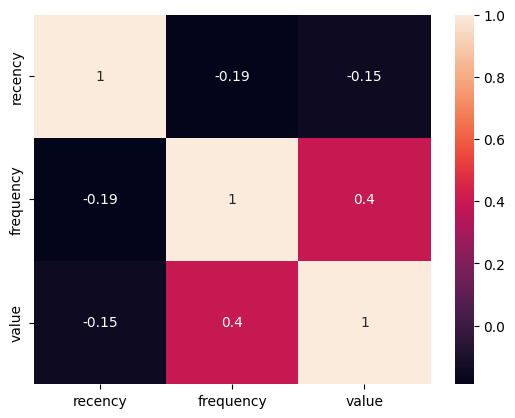

In [49]:
sns.heatmap(rfm.corr(), annot=True)

# negative correlation between recency and frequency- less recency leading to more frequency ; more recency leading to less frequency
# negative correlation between recency and monetary value- less recency led to more monetary value and more recency led to higher monetary value
# positive correlation between frequency and value- higher frequency led to higher value; lower frequency led to lower value

In [50]:
from sklearn.cluster import KMeans

In [51]:
clusters = list(range(2,11))
ssd=[]
for i in clusters:
    model=KMeans(n_clusters=i, random_state=42)
    model.fit(rfm_normalized)
    ssd.append(model.inertia_)

In [52]:
ssd

[16436.036064062726,
 11340.637907790711,
 9055.454362481012,
 6710.329068709564,
 4864.197076032799,
 4476.947065828831,
 3632.8883762213495,
 3423.467731479101,
 2853.820703738377]

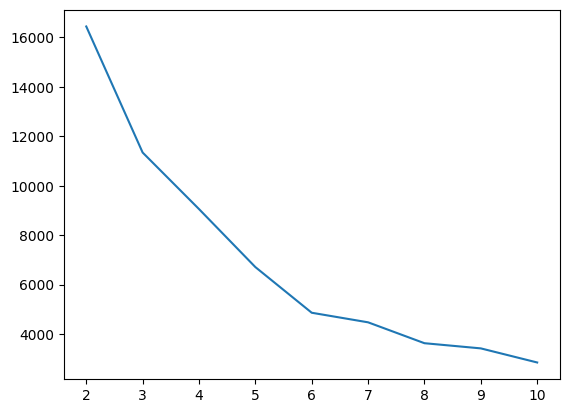

In [53]:
plt.plot(clusters,ssd)

In [54]:
# We can see the optimal number of clusters is 8

In [55]:
model=KMeans(n_clusters=8, random_state=42)
model.fit(rfm_normalized)

KMeans(random_state=42)

In [56]:
model.labels_

array([1, 0, 7, ..., 0, 0, 0])

In [57]:
rfm_normalized['category']=model.labels_
rfm_normalized.reset_index(inplace=True)
rfm_normalized

,CustomerID,recency,frequency,value,category
0,12346.0,1.666981,-0.361999,-0.217265,1
1,12747.0,-1.160855,0.215542,0.627486,0
2,12748.0,-1.178365,26.170553,5.635605,7
3,12749.0,-1.152100,0.947474,0.561491,4
4,12820.0,-1.152100,-0.036060,-0.027551,0
...,...,...,...,...,...
7582,C577779,-1.020776,-0.356281,-0.275246,0
7583,C578097,-1.029531,-0.333408,-0.460471,0
7584,C579757,-1.099570,-0.367717,-0.220406,0
7585,C580604,-1.143345,-0.367717,-2.549889,0


In [58]:
cat=rfm_normalized['category'].value_counts().reset_index()
cat

,index,category
0,0,3472
1,5,1826
2,1,1817
3,4,437
4,6,25
5,2,5
6,7,3
7,3,2


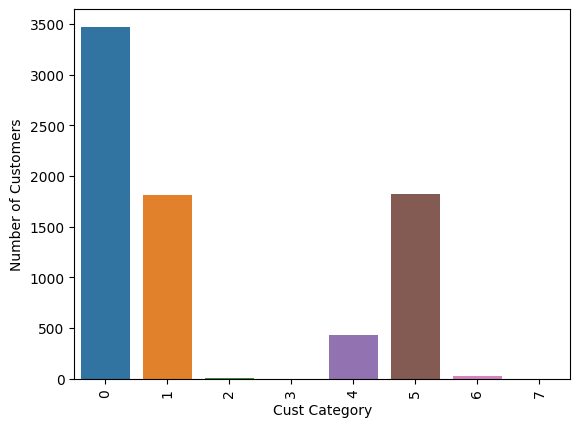

In [59]:
sns.barplot(x=cat['index'], y=cat['category'])
plt.xticks(rotation=90)
plt.xlabel('Cust Category')
plt.ylabel('Number of Customers')
plt.show()

In [60]:
rfm.reset_index(inplace=True)
rfm.head(5)

,CustomerID,recency,frequency,value,recency_category,frequency_category,value_category,cust_category
0,12346.0,5028,2,0.00,H,L,L,Recent Customers
1,12747.0,4705,103,4196.01,L,H,H,Can’t Lose
2,12748.0,4703,4642,29072.10,L,H,H,Can’t Lose
3,12749.0,4706,231,3868.20,L,H,H,Can’t Lose
4,12820.0,4706,59,942.34,L,H,H,Can’t Lose


In [61]:
final=rfm.drop(columns=['recency','frequency','value','recency_category','frequency_category','value_category'])
final

,CustomerID,cust_category
0,12346.0,Recent Customers
1,12747.0,Can’t Lose
2,12748.0,Can’t Lose
3,12749.0,Can’t Lose
4,12820.0,Can’t Lose
...,...,...
7582,C577779,Lost
7583,C578097,Lost
7584,C579757,Lost
7585,C580604,Lost


In [62]:
final=final.merge(rfm_normalized, on='CustomerID')

In [63]:
final=final.drop(columns=['recency','frequency','value'])


In [64]:
final.head(20)

,CustomerID,cust_category,category
0,12346.0,Recent Customers,1
1,12747.0,Can’t Lose,0
2,12748.0,Can’t Lose,7
3,12749.0,Can’t Lose,4
4,12820.0,Can’t Lose,0
5,12821.0,Recent Customers,5
6,12822.0,Can’t Lose,0
7,12823.0,Needing Attention,0
8,12824.0,Can’t Lose,0
9,12826.0,Can’t Lose,0
